# INT20H 2026 — Payment Transaction Anomaly Detection

**Task:** Label each of 1,000,000 payment transactions as anomalous (1) or normal (0).  
**Metric:** F1-Score  
**Approach:** Rule-based domain anomaly detection + Isolation Forest (unsupervised ML), ensemble combined.

## Table of Contents
1. [Setup](#1-setup)
2. [Data Loading & Overview](#2-data-loading)
3. [Exploratory Data Analysis](#3-eda)
4. [Feature Engineering](#4-features)
5. [Rule-Based Anomaly Detection](#5-rules)
6. [ML-Based Detection (Isolation Forest)](#6-isolation-forest)
7. [Ensemble & Final Decision](#7-ensemble)
8. [Deep-Dive Anomaly Analysis](#8-analysis)
9. [Submission](#9-submission)

## 1. Setup <a id='1-setup'></a>

In [1]:
!pip3 install scikit-learn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_PATH = 'data/hackathon_int20h_dataset_test.csv'
OUTPUT_PATH = 'submission.csv'

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading & Overview <a id='2-data-loading'></a>

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (1000000, 18)


,created_at,order_id,processed_at,order_type,user_id,ip_country,currency,amount,payment_method,order_payment_type,bin_country,bank_id,psp_id,has_refund,refunded_amount,is_secured,status,error_code
0,2025-07-01 09:21:23,1,2025-07-01 09:21:32,first,692925,DEU,EUR,4.6000,googlepay,NaN,GBR,32,psp_alpha,False,0.0000,False,fail,3.0200
1,2025-09-01 01:15:47,2,2025-09-01 01:15:57,recurring,452913,CAN,CAD,54.8000,card,recurring,CAN,1,psp_alpha,False,0.0000,False,success,NaN
2,2025-06-24 23:38:35,3,2025-06-24 23:38:39,first,784680,USA,USD,9.9900,card,NaN,USA,32,psp_alpha,False,0.0000,False,fail,2.0100
3,2025-04-23 04:42:13,4,2025-04-23 04:42:21,first,300037,CAN,CAD,1.3700,card,NaN,CAN,31,psp_gamma,False,0.0000,False,fail,3.0400
4,2025-03-14 20:15:32,5,2025-03-14 20:15:42,first,996803,DEU,EUR,0.9200,card,NaN,GBR,39,psp_beta,False,0.0000,False,fail,2.1200


In [4]:
df.dtypes

created_at             object
order_id                int64
processed_at           object
order_type             object
user_id                 int64
ip_country             object
currency               object
amount                float64
payment_method         object
order_payment_type     object
bin_country            object
bank_id                 int64
psp_id                 object
has_refund               bool
refunded_amount       float64
is_secured               bool
status                 object
error_code            float64
dtype: object

In [ ]:
# Missing values
null_counts = df.isnull().sum()
empty_str_counts = (df == '').sum()
print('=== Null values ===')
print(null_counts[null_counts > 0])
print('\n=== Empty string values (by column) ===')
print(empty_str_counts[empty_str_counts > 0])

=== Null values ===
order_payment_type    400526
error_code            525114
dtype: int64

=== Empty string values (by column) ===
Series([], dtype: int64)


In [6]:
df.describe()

,order_id,user_id,amount,bank_id,refunded_amount,error_code
count,1000000.0000,1000000.0000,1000000.0000,1000000.0000,1000000.0000,474886.0000
mean,500000.5000,550083.8049,115.1337,25.4743,2.3394,2.9055
std,288675.2789,259853.8679,390.9722,23.6374,43.6277,0.4976
min,1.0000,100002.0000,0.7800,1.0000,0.0000,0.0100
25%,250000.7500,324983.0000,9.9900,13.0000,0.0000,3.0200
50%,500000.5000,550019.0000,20.1000,25.0000,0.0000,3.0200
75%,750000.2500,775152.5000,50.0000,37.0000,0.0000,3.0800
max,1000000.0000,999997.0000,8240.0000,777.0000,6190.0000,5.0100


In [7]:
# Categorical column cardinalities
cat_cols = ['order_type', 'payment_method', 'order_payment_type', 'currency',
            'status', 'is_secured', 'has_refund', 'psp_id']
for col in cat_cols:
    print(f'{col}: {sorted(df[col].dropna().unique().tolist(), key=str)}')

order_type: ['first', 'recurring']
payment_method: ['applepay', 'card', 'googlepay']
order_payment_type: ['1-click', 'rebill', 'recurring', 'retry']
currency: ['CAD', 'EUR', 'GBP', 'MXN', 'PLN', 'UAH', 'USD']
status: ['fail', 'success']
is_secured: [False, True]
has_refund: [False, True]
psp_id: ['psp_alpha', 'psp_beta', 'psp_gamma']


## 3. Exploratory Data Analysis <a id='3-eda'></a>

### 3.1 Status & Payment Method Distributions

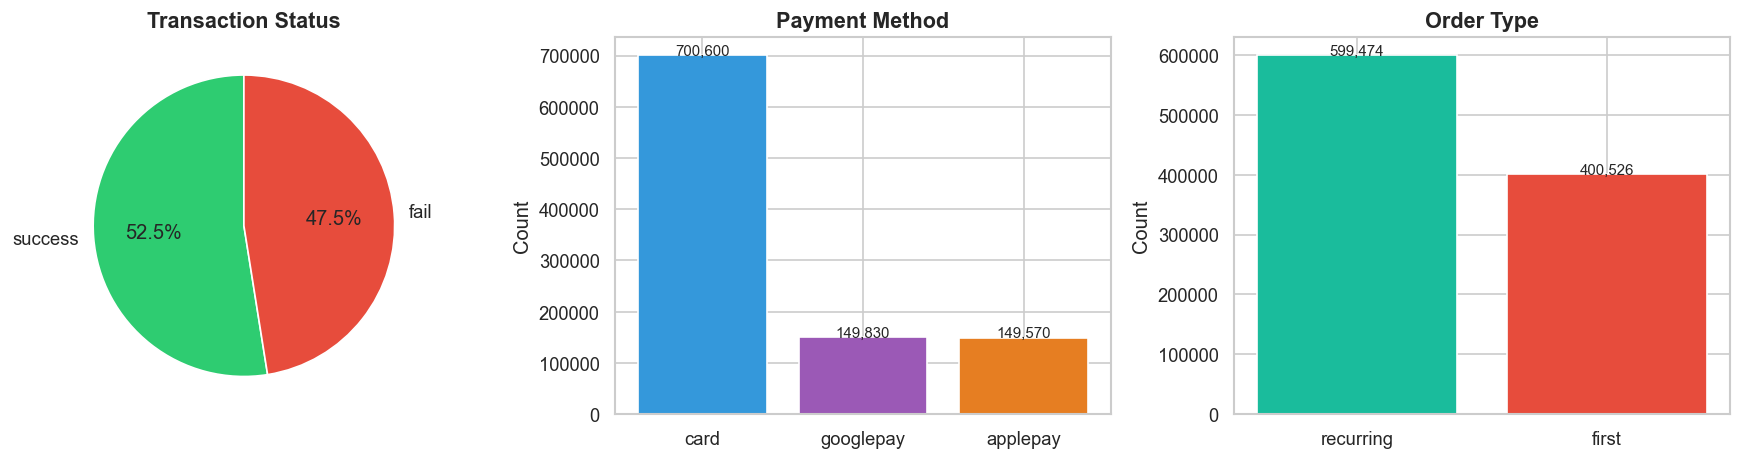


Overall fail rate: 47.49%


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Status
status_counts = df['status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Transaction Status', fontsize=13, fontweight='bold')

# Payment method
pm_counts = df['payment_method'].value_counts()
axes[1].bar(pm_counts.index, pm_counts.values, color=['#3498db', '#9b59b6', '#e67e22'])
axes[1].set_title('Payment Method', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(pm_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Order type
ot_counts = df['order_type'].value_counts()
axes[2].bar(ot_counts.index, ot_counts.values, color=['#1abc9c', '#e74c3c'])
axes[2].set_title('Order Type', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Count')
for i, v in enumerate(ot_counts.values):
    axes[2].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'\nOverall fail rate: {(df["status"]=="fail").mean():.2%}')

### 3.2 Amount Distribution

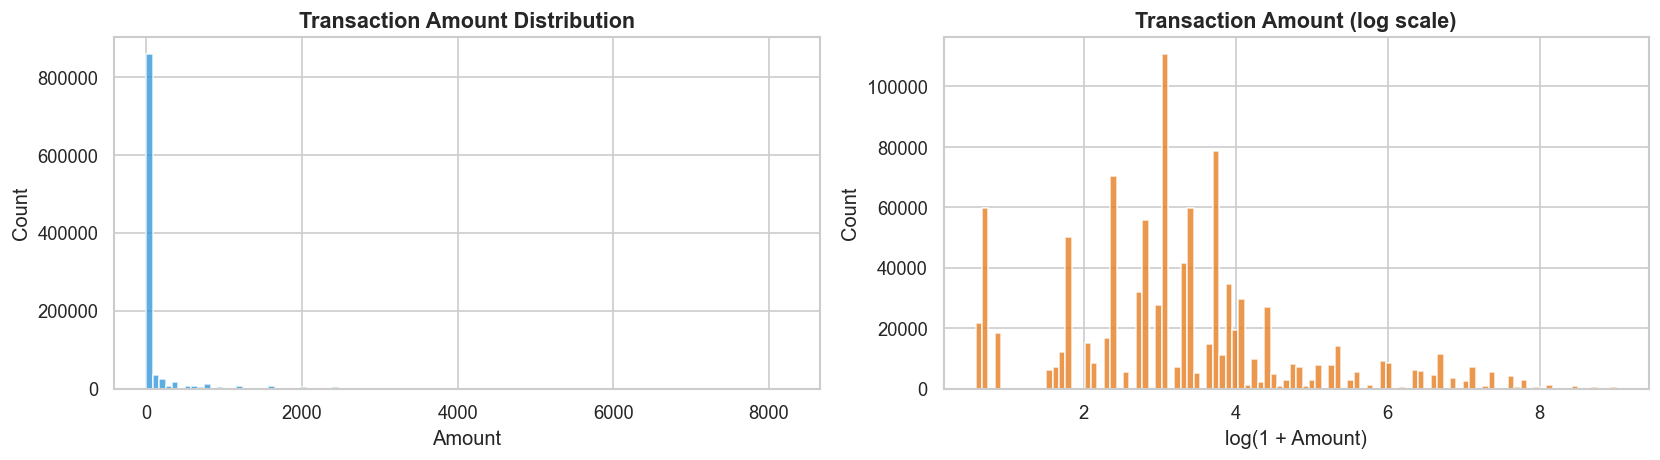

count   1000000.0000
mean        115.1337
std         390.9722
min           0.7800
25%           9.9900
50%          20.1000
75%          50.0000
95%         618.0000
99%        2060.0000
99.9%      4944.0000
max        8240.0000
Name: amount, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['amount'], bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Transaction Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['amount']), bins=100, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].set_title('Transaction Amount (log scale)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + Amount)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df['amount'].describe(percentiles=[.25, .5, .75, .95, .99, .999]))

### 3.3 Processing Time Analysis

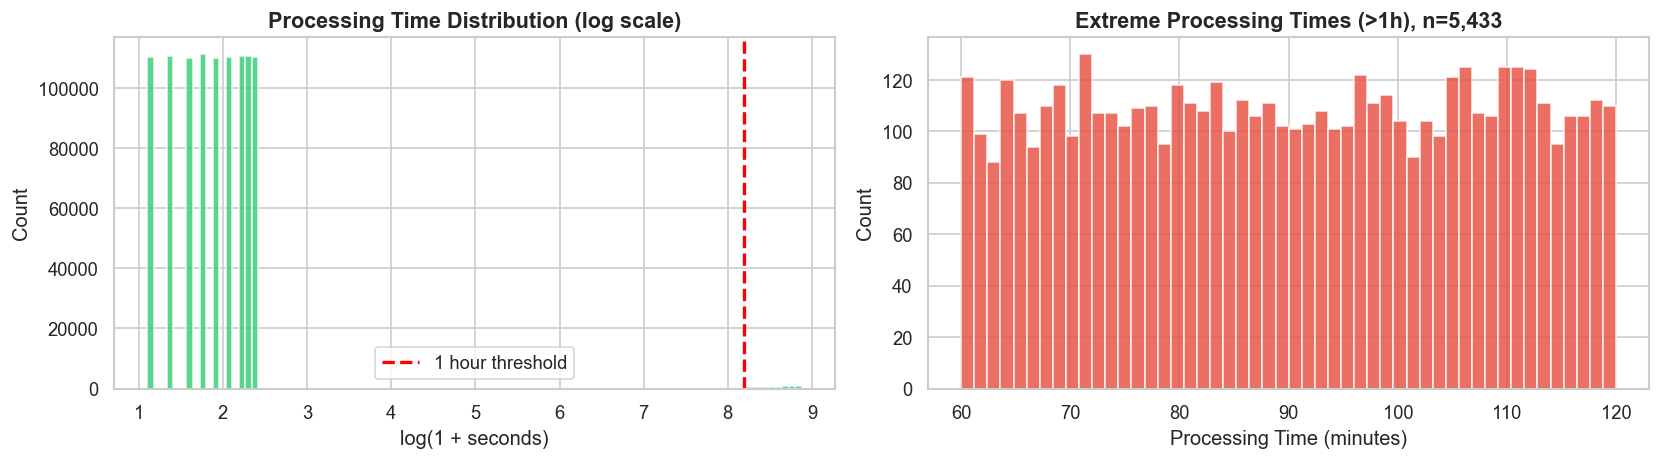

count   1000000.0000
mean         35.3624
std         404.6237
min           2.0000
50%           6.0000
95%          10.0000
99%          10.0000
99.9%      6561.0000
max        7199.0000
Name: processing_time, dtype: float64
Negative processing times: 0
Processing time > 3600s: 5,433 (0.54%)


In [10]:
# Parse timestamps early for EDA
df['created_at'] = pd.to_datetime(df['created_at'])
df['processed_at'] = pd.to_datetime(df['processed_at'])
df['processing_time'] = (df['processed_at'] - df['created_at']).dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(np.log1p(df['processing_time']), bins=100, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[0].axvline(np.log1p(3600), color='red', linestyle='--', linewidth=2, label='1 hour threshold')
axes[0].set_title('Processing Time Distribution (log scale)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log(1 + seconds)')
axes[0].set_ylabel('Count')
axes[0].legend()

extreme = df[df['processing_time'] > 3600]['processing_time']
if len(extreme) > 0:
    axes[1].hist(extreme / 60, bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[1].set_title(f'Extreme Processing Times (>1h), n={len(extreme):,}', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Processing Time (minutes)')
    axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(df['processing_time'].describe(percentiles=[.5, .95, .99, .999]))
print(f'Negative processing times: {(df["processing_time"] < 0).sum()}')
print(f'Processing time > 3600s: {(df["processing_time"] > 3600).sum():,} ({(df["processing_time"] > 3600).mean():.2%})')

### 3.4 Error Codes & Geographic Analysis

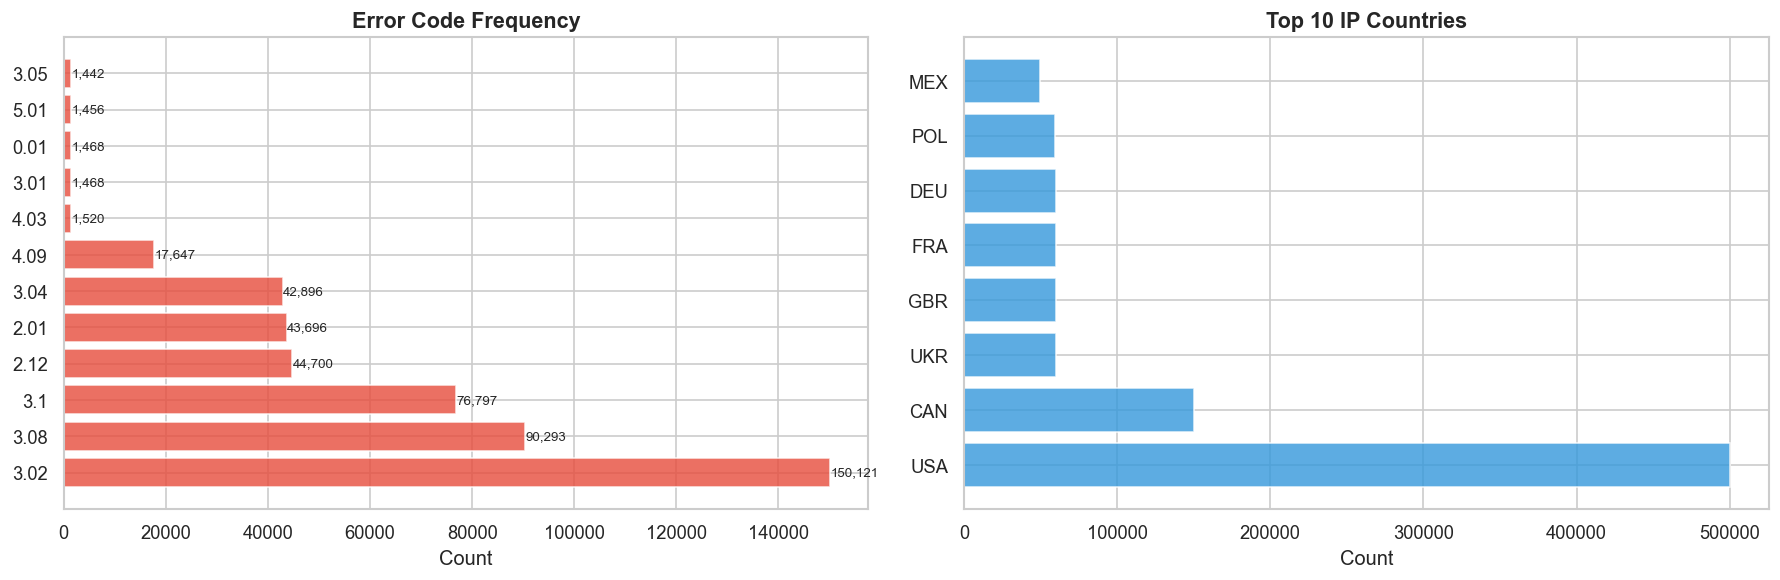

Geo mismatch rate (IP country != BIN country): 14.43%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# error_code is float64; filter NaN to get failed transactions only
error_counts = df['error_code'].dropna().value_counts().head(12)
axes[0].barh(error_counts.index.astype(str), error_counts.values, color='#e74c3c', alpha=0.8)
axes[0].set_title('Error Code Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for i, v in enumerate(error_counts.values):
    axes[0].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

top_ip = df['ip_country'].value_counts().head(10)
axes[1].barh(top_ip.index, top_ip.values, color='#3498db', alpha=0.8)
axes[1].set_title('Top 10 IP Countries', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

geo_mismatch_rate = (df['ip_country'] != df['bin_country']).mean()
print(f'Geo mismatch rate (IP country != BIN country): {geo_mismatch_rate:.2%}')

### 3.5 Temporal Patterns

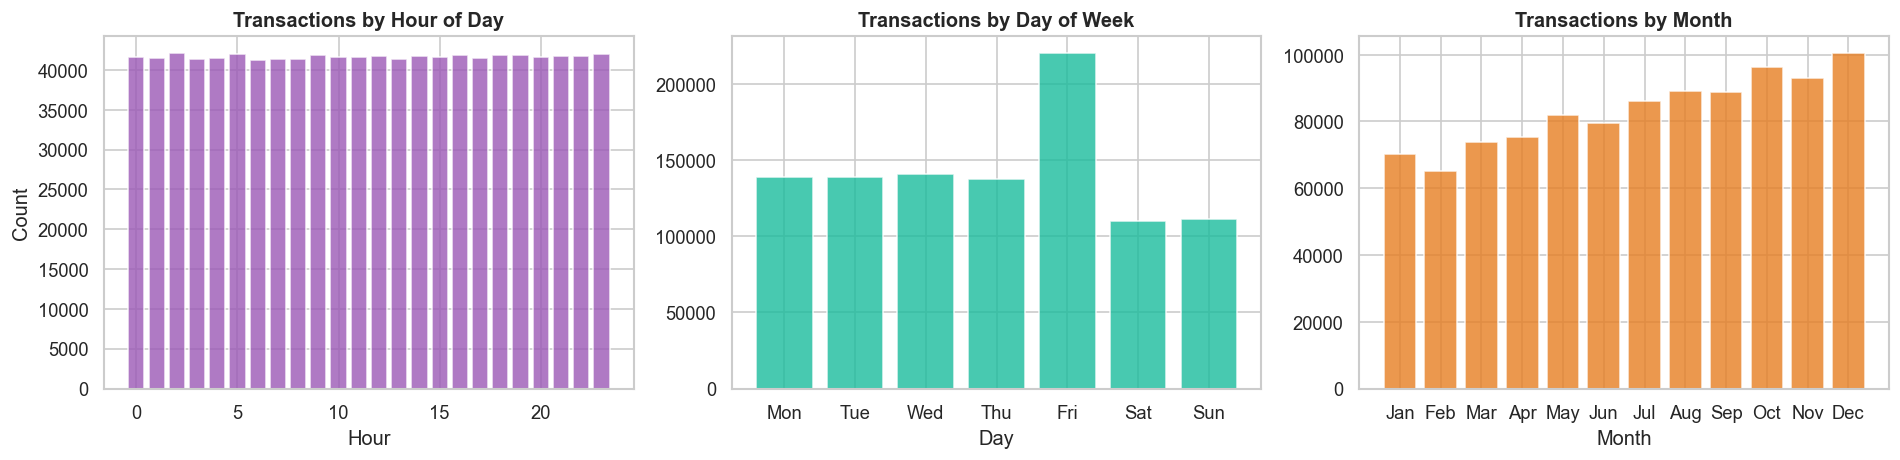

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

hour_counts = df['created_at'].dt.hour.value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color='#9b59b6', alpha=0.8)
axes[0].set_title('Transactions by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

dow_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
dow_counts = df['created_at'].dt.dayofweek.value_counts().sort_index()
axes[1].bar([dow_map[i] for i in dow_counts.index], dow_counts.values, color='#1abc9c', alpha=0.8)
axes[1].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')

month_map = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
             7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
month_counts = df['created_at'].dt.month.value_counts().sort_index()
axes[2].bar([month_map[i] for i in month_counts.index], month_counts.values, color='#e67e22', alpha=0.8)
axes[2].set_title('Transactions by Month', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Month')

plt.tight_layout()
plt.show()

### 3.6 Refund Analysis

In [13]:
print(f'Has refund distribution: {df["has_refund"].value_counts().to_dict()}')
print(f'Refund rate: {(df["has_refund"] == True).mean():.2%}')

refund_df = df[df['has_refund'] == True]
print(f'\nRefund amount stats (for refunded orders):')
print(refund_df['refunded_amount'].describe())

over_refund_mask = df['refunded_amount'] > df['amount']
print(f'\nOver-refund (refunded > charged): {over_refund_mask.sum():,} ({over_refund_mask.mean():.2%})')
df[over_refund_mask][['order_id', 'amount', 'refunded_amount', 'currency', 'status']].head(5)

Has refund distribution: {False: 962986, True: 37014}
Refund rate: 3.70%

Refund amount stats (for refunded orders):
count   37014.0000
mean       63.2021
std       218.1233
min         0.3900
25%         5.0000
50%        13.7000
75%        27.4000
max      6190.0000
Name: refunded_amount, dtype: float64

Over-refund (refunded > charged): 2,691 (0.27%)


,order_id,amount,refunded_amount,currency,status
57,58,41.2000,51.2000,UAH,success
826,827,370.0000,380.0000,MXN,success
1798,1799,20.0000,30.0000,USD,success
2377,2378,40.1600,50.1600,PLN,success
2435,2436,10.0000,20.0000,USD,success


### 3.7 Fail Rate by Bank and PSP

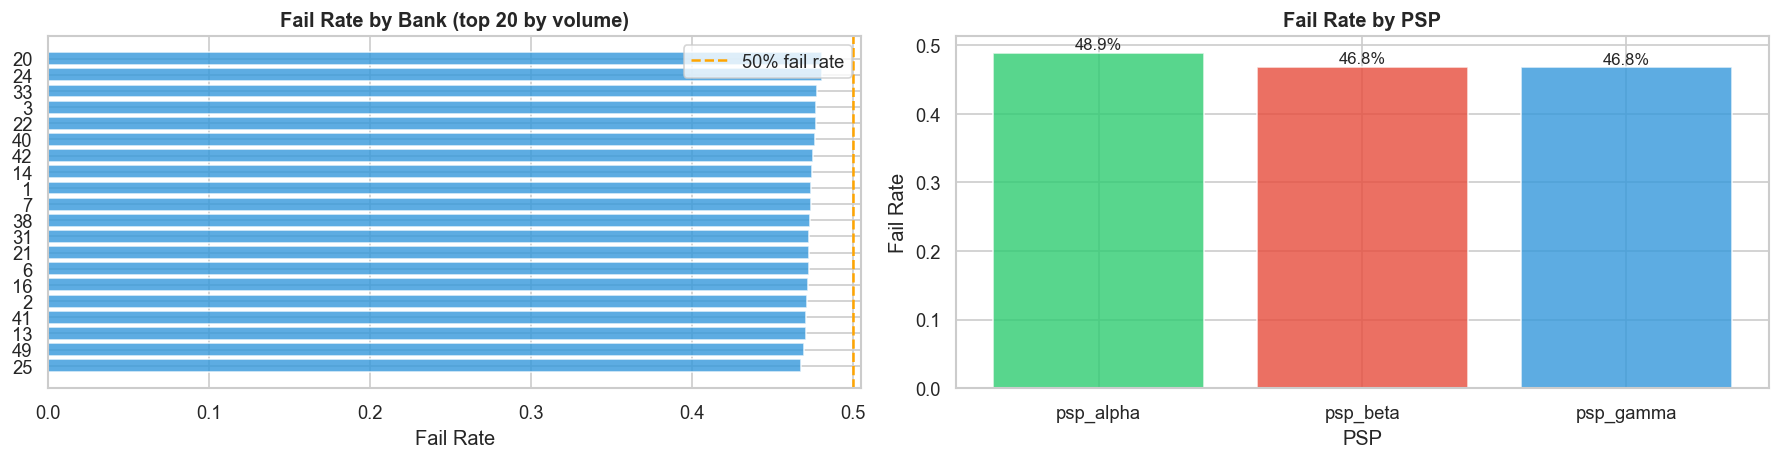

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

bank_stats_eda = df.groupby('bank_id').agg(
    tx_count=('order_id', 'count'),
    fail_rate=('status', lambda x: (x == 'fail').mean())
).reset_index()
top_banks = bank_stats_eda.nlargest(20, 'tx_count').sort_values('fail_rate')
colors = ['#e74c3c' if r > 0.7 else '#3498db' for r in top_banks['fail_rate']]
axes[0].barh(top_banks['bank_id'].astype(str), top_banks['fail_rate'], color=colors, alpha=0.8)
axes[0].axvline(0.5, color='orange', linestyle='--', label='50% fail rate')
axes[0].set_title('Fail Rate by Bank (top 20 by volume)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fail Rate')
axes[0].legend()

psp_stats_eda = df.groupby('psp_id').agg(
    tx_count=('order_id', 'count'),
    fail_rate=('status', lambda x: (x == 'fail').mean())
).reset_index()
axes[1].bar(psp_stats_eda['psp_id'], psp_stats_eda['fail_rate'],
            color=['#2ecc71', '#e74c3c', '#3498db'], alpha=0.8)
axes[1].set_title('Fail Rate by PSP', fontsize=12, fontweight='bold')
axes[1].set_xlabel('PSP')
axes[1].set_ylabel('Fail Rate')
for i, (_, row) in enumerate(psp_stats_eda.iterrows()):
    axes[1].text(i, row['fail_rate'] + 0.005, f'{row["fail_rate"]:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Feature Engineering <a id='4-features'></a>

### 4.1 Temporal Features

In [15]:
# processing_time already computed during EDA
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek
df['month'] = df['created_at'].dt.month
df['is_night'] = df['hour'].between(1, 5).astype(int)   # 1–5 AM = suspicious hours
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print('Temporal features created.')
print(f'Night transactions (1–5 AM): {df["is_night"].sum():,} ({df["is_night"].mean():.2%})')

Temporal features created.
Night transactions (1–5 AM): 208,507 (20.85%)


### 4.2 Geographic & Security Features

In [16]:
df['is_geo_mismatch'] = (df['ip_country'] != df['bin_country']).astype(int)
# is_secured is already bool dtype
df['is_secured_num'] = df['is_secured'].astype(int)

print(f'Geo mismatch: {df["is_geo_mismatch"].sum():,} ({df["is_geo_mismatch"].mean():.2%})')
print(f'3DS secured:  {df["is_secured_num"].sum():,} ({df["is_secured_num"].mean():.2%})')

Geo mismatch: 144,262 (14.43%)
3DS secured:  42,337 (4.23%)


### 4.3 Transaction Status & Error Features

In [17]:
df['is_failed'] = (df['status'] == 'fail').astype(int)

# error_code is float64 (e.g. 3.02, 5.01); NaN = success (no error)
# Extract integer prefix: 5.xx -> '5', 3.xx -> '3', NaN -> '0'
# Solidgate severity: 5.xx = fraud/security, 4.xx = client/card, 3.xx = bank decline, 2.xx = invalid data
df['error_prefix'] = df['error_code'].apply(
    lambda x: str(int(x)) if pd.notna(x) else '0'
)
df['is_fraud_error'] = (df['error_prefix'] == '5').astype(int)
df['error_severity'] = df['error_prefix'].map({'0': 0, '2': 1, '3': 2, '4': 3, '5': 4}).fillna(0)

print(f'Fraud error (5.xx): {df["is_fraud_error"].sum():,} ({df["is_fraud_error"].mean():.2%})')
print(f'Error severity distribution:\n{df["error_severity"].value_counts().sort_index()}')

Fraud error (5.xx): 1,456 (0.15%)
Error severity distribution:
error_severity
0    526582
1     89778
2    363017
3     19167
4      1456
Name: count, dtype: int64


### 4.4 Payment Type Consistency Features

In [18]:
# Apple Pay / Google Pay only support Customer-Initiated Transactions (CIT / 1-click)
# They do NOT support automated billing (rebill/recurring/retry) — that requires card tokenization
# Finding wallet payment method with automated billing type = data anomaly / fraud pattern
df['is_wallet_autobilling'] = (
    df['payment_method'].isin(['googlepay', 'applepay']) &
    df['order_payment_type'].isin(['rebill', 'recurring', 'retry'])
).astype(int)

print(f'Wallet + automated billing: {df["is_wallet_autobilling"].sum():,} ({df["is_wallet_autobilling"].mean():.2%})')
df[df['is_wallet_autobilling'] == 1].groupby(['payment_method', 'order_payment_type']).size().reset_index(name='count')

Wallet + automated billing: 134,254 (13.43%)


,payment_method,order_payment_type,count
0,applepay,rebill,22330
1,applepay,recurring,22299
2,applepay,retry,22384
3,googlepay,rebill,22501
4,googlepay,recurring,22017
5,googlepay,retry,22723


### 4.5 Refund Anomaly Features

In [19]:
df['refund_ratio'] = df['refunded_amount'] / (df['amount'] + 1e-8)
df['is_over_refund'] = (df['refunded_amount'] > df['amount']).astype(int)
df['refund_inconsistency'] = (
    (df['has_refund'] == True) & (df['refunded_amount'] == 0)
).astype(int)

print(f'Over-refund:           {df["is_over_refund"].sum():,} ({df["is_over_refund"].mean():.2%})')
print(f'Refund inconsistency:  {df["refund_inconsistency"].sum():,} ({df["refund_inconsistency"].mean():.2%})')

Over-refund:           2,691 (0.27%)
Refund inconsistency:  0 (0.00%)


### 4.6 User-Level Aggregations

In [20]:
user_stats = df.groupby('user_id').agg(
    user_tx_count=('order_id', 'count'),
    user_fail_rate=('is_failed', 'mean'),
    user_amount_mean=('amount', 'mean'),
    user_amount_std=('amount', 'std'),
    user_geo_mismatch_rate=('is_geo_mismatch', 'mean'),
    user_fraud_error_rate=('is_fraud_error', 'mean'),
).reset_index()

df = df.merge(user_stats, on='user_id')

# How far this transaction's amount deviates from user's historical average
df['amount_zscore_user'] = (
    (df['amount'] - df['user_amount_mean']) /
    df['user_amount_std'].clip(lower=1)
)

print('User-level features created.')
print(f'Users with high fail rate (>0.9, >5 tx): '
      f'{((user_stats["user_fail_rate"] > 0.9) & (user_stats["user_tx_count"] > 5)).sum():,}')

User-level features created.
Users with high fail rate (>0.9, >5 tx): 6


### 4.7 User Velocity (Transactions per Hour)

Max transactions per hour by single user: 2
Users with >5 tx/hour: 0 (0.00%)


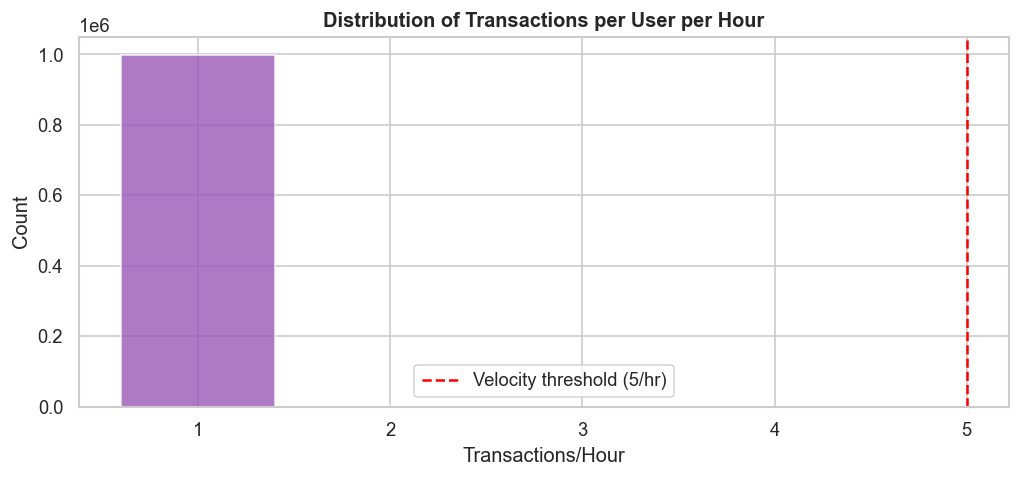

In [21]:
# Count transactions per (user, hour-slot) — efficient O(n) approach
df['hour_key'] = df['created_at'].dt.floor('h')
user_hour = (
    df.groupby(['user_id', 'hour_key'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'user_tx_per_hour'})
)
df = df.merge(user_hour, on=['user_id', 'hour_key'])

print(f'Max transactions per hour by single user: {df["user_tx_per_hour"].max()}')
print(f'Users with >5 tx/hour: {(df["user_tx_per_hour"] > 5).sum():,} ({(df["user_tx_per_hour"] > 5).mean():.2%})')

velocity_dist = df['user_tx_per_hour'].value_counts().sort_index().head(20)
plt.figure(figsize=(10, 4))
plt.bar(velocity_dist.index, velocity_dist.values, color='#9b59b6', alpha=0.8)
plt.axvline(5, color='red', linestyle='--', label='Velocity threshold (5/hr)')
plt.title('Distribution of Transactions per User per Hour', fontsize=12, fontweight='bold')
plt.xlabel('Transactions/Hour')
plt.ylabel('Count')
plt.legend()
plt.show()

### 4.8 Bank & PSP Aggregations

In [22]:
bank_agg = df.groupby('bank_id').agg(
    bank_fail_rate=('is_failed', 'mean'),
    bank_tx_count=('order_id', 'count'),
).reset_index()
df = df.merge(bank_agg, on='bank_id')

psp_agg = df.groupby('psp_id').agg(
    psp_fail_rate=('is_failed', 'mean'),
).reset_index()
df = df.merge(psp_agg, on='psp_id')

print('Bank and PSP features created.')
print(f'Bank fail rate range: {df["bank_fail_rate"].min():.2%} – {df["bank_fail_rate"].max():.2%}')

Bank and PSP features created.
Bank fail rate range: 46.74% – 100.00%


In [23]:
# Summary of all engineered features
feature_cols = [
    'processing_time', 'hour', 'day_of_week', 'month', 'is_night', 'is_weekend',
    'is_geo_mismatch', 'is_secured_num', 'is_failed', 'is_fraud_error', 'error_severity',
    'is_wallet_autobilling', 'refund_ratio', 'is_over_refund', 'refund_inconsistency',
    'user_tx_count', 'user_fail_rate', 'user_amount_mean', 'user_amount_std',
    'user_geo_mismatch_rate', 'user_fraud_error_rate', 'amount_zscore_user',
    'user_tx_per_hour', 'bank_fail_rate', 'bank_tx_count', 'psp_fail_rate'
]
print(f'Total engineered features: {len(feature_cols)}')
df[feature_cols].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

Total engineered features: 26


,mean,std,min,25%,50%,75%,max
processing_time,35.3624,404.6237,2.0000,4.0000,6.0000,8.0000,7199.0000
hour,11.5112,6.9266,0.0000,5.0000,12.0000,18.0000,23.0000
day_of_week,2.9390,1.9011,0.0000,1.0000,3.0000,4.0000,6.0000
month,6.9177,3.4257,1.0000,4.0000,7.0000,10.0000,12.0000
is_night,0.2085,0.4062,0.0000,0.0000,0.0000,0.0000,1.0000
is_weekend,0.2219,0.4156,0.0000,0.0000,0.0000,0.0000,1.0000
is_geo_mismatch,0.1443,0.3514,0.0000,0.0000,0.0000,0.0000,1.0000
is_secured_num,0.0423,0.2014,0.0000,0.0000,0.0000,0.0000,1.0000
is_failed,0.4749,0.4994,0.0000,0.0000,0.0000,1.0000,1.0000
is_fraud_error,0.0015,0.0381,0.0000,0.0000,0.0000,0.0000,1.0000


## 5. Rule-Based Anomaly Detection <a id='5-rules'></a>

Domain-driven rules capture **explainable, high-confidence anomalies**. Each rule is backed by payment industry knowledge:

| Rule | Description | Rationale |
|------|-------------|----------|
| **R1** | Processing time > 3600s | Normal bank processing: 2–30s. Hours-long delays = technical timeout / stuck transaction |
| **R2** | Refunded amount > charged amount | Mathematical impossibility in legitimate billing = accounting fraud or system error |
| **R3** | Solidgate 5.xx error code | Reserved for confirmed fraud/security events (stolen cards, suspicious patterns flagged by bank) |
| **R4** | Digital wallet with automated billing | Apple/Google Pay are customer-initiated only; rebill/recurring use card tokens, not wallet sessions |
| **R5** | Geo mismatch + failed + no 3DS | Classic card-not-present fraud: foreign card, no authentication, declined |
| **R6** | Amount z-score > 5 (per-user) | 5+ std deviations from user's normal spending = highly unusual transaction |
| **R7** | >5 transactions/hour (same user) | Velocity attack: bots testing stolen cards or automated fraud |
| **R8** | has_refund=True but refunded_amount=0 | Data integrity inconsistency = potential system error or manipulation |

In [24]:
rules = {
    'R1_extreme_proc_time':    df['processing_time'] > 3600,
    'R2_over_refund':          df['is_over_refund'] == 1,
    'R3_fraud_error':          df['is_fraud_error'] == 1,
    'R4_wallet_autobilling':   df['is_wallet_autobilling'] == 1,
    'R5_geo_fail_unsecured':   (
        (df['is_geo_mismatch'] == 1) &
        (df['is_failed'] == 1) &
        (df['is_secured_num'] == 0)
    ),
    'R6_extreme_amount':       df['amount_zscore_user'].abs() > 5,
    'R7_high_velocity':        df['user_tx_per_hour'] > 5,
    'R8_refund_inconsistency': df['refund_inconsistency'] == 1,
}

for name, mask in rules.items():
    df[name] = mask.astype(int)

rule_names = list(rules.keys())
df['rule_score'] = df[rule_names].sum(axis=1)
df['rule_anomaly'] = (df['rule_score'] >= 1).astype(int)

print('=== Rule Trigger Counts ===')
for name in rule_names:
    count = df[name].sum()
    print(f'  {name}: {count:,} ({count/len(df):.2%})')
print(f'\nTotal rule-flagged anomalies: {df["rule_anomaly"].sum():,} ({df["rule_anomaly"].mean():.2%})')

=== Rule Trigger Counts ===
  R1_extreme_proc_time: 5,433 (0.54%)
  R2_over_refund: 2,691 (0.27%)
  R3_fraud_error: 1,456 (0.15%)
  R4_wallet_autobilling: 134,254 (13.43%)
  R5_geo_fail_unsecured: 65,922 (6.59%)
  R6_extreme_amount: 0 (0.00%)
  R7_high_velocity: 0 (0.00%)
  R8_refund_inconsistency: 0 (0.00%)

Total rule-flagged anomalies: 198,888 (19.89%)


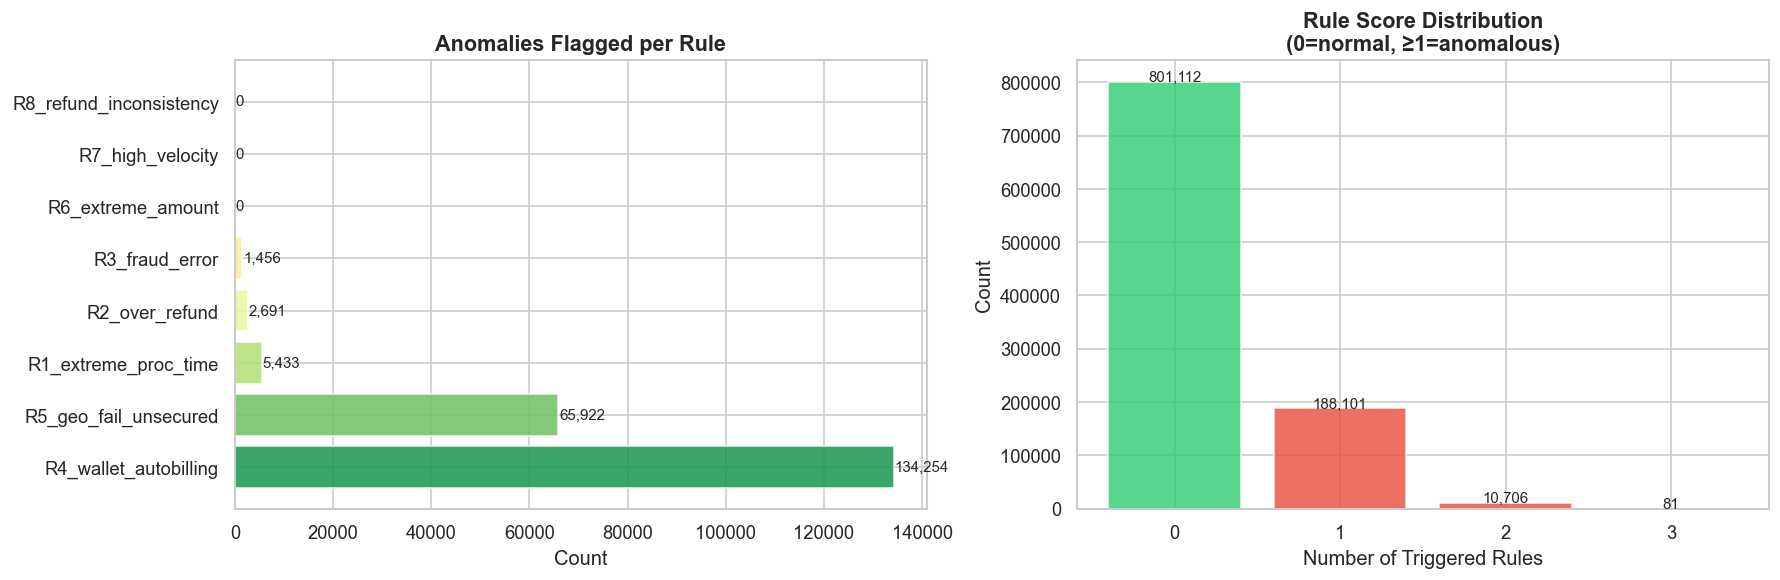

In [25]:
rule_counts = {name: df[name].sum() for name in rule_names}
sorted_rules = sorted(rule_counts.items(), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

labels = [r[0] for r in sorted_rules]
counts = [r[1] for r in sorted_rules]
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(counts)))
bars = axes[0].barh(labels, counts, color=colors_bar, alpha=0.85)
axes[0].set_title('Anomalies Flagged per Rule', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{count:,}', va='center', fontsize=9)

score_counts = df['rule_score'].value_counts().sort_index()
bar_colors = ['#2ecc71' if i == 0 else '#e74c3c' for i in score_counts.index]
axes[1].bar(score_counts.index.astype(str), score_counts.values, color=bar_colors, alpha=0.8)
axes[1].set_title('Rule Score Distribution\n(0=normal, ≥1=anomalous)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Triggered Rules')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(zip(score_counts.index, score_counts.values)):
    axes[1].text(i, val + 1000, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. ML-Based Detection: Isolation Forest <a id='6-isolation-forest'></a>

**Why Isolation Forest?**
- Unsupervised (no labels required) — perfect for this task
- Efficient on large datasets (O(n log n))
- Isolates anomalies through random feature partitioning: anomalies are isolated in fewer splits
- Naturally handles mixed numeric features without distribution assumptions
- `contamination=0.05` = we expect approximately 5% anomaly rate

In [26]:
ml_features = [
    'processing_time', 'amount', 'hour', 'day_of_week', 'month',
    'is_night', 'is_weekend', 'is_geo_mismatch', 'is_failed',
    'is_secured_num', 'refund_ratio', 'is_over_refund',
    'user_tx_count', 'user_fail_rate', 'user_amount_mean',
    'amount_zscore_user', 'user_geo_mismatch_rate', 'user_fraud_error_rate',
    'user_tx_per_hour', 'bank_fail_rate', 'psp_fail_rate',
    'is_wallet_autobilling', 'is_fraud_error', 'error_severity',
    'refund_inconsistency'
]

print(f'Feature count: {len(ml_features)}')
X = df[ml_features].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Feature matrix shape: {X_scaled.shape}')

Feature count: 25
Feature matrix shape: (1000000, 25)


In [27]:
print('Training Isolation Forest on 1,000,000 transactions...')

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

df['if_pred'] = iso_forest.predict(X_scaled)      # -1 = anomaly, 1 = normal
df['if_score'] = iso_forest.score_samples(X_scaled)  # lower = more anomalous
df['if_anomaly'] = (df['if_pred'] == -1).astype(int)

print(f'IF flagged anomalies: {df["if_anomaly"].sum():,} ({df["if_anomaly"].mean():.2%})')
print(f'IF score range: {df["if_score"].min():.4f} – {df["if_score"].max():.4f}')

Training Isolation Forest on 1,000,000 transactions...
IF flagged anomalies: 50,000 (5.00%)
IF score range: -0.6948 – -0.3806


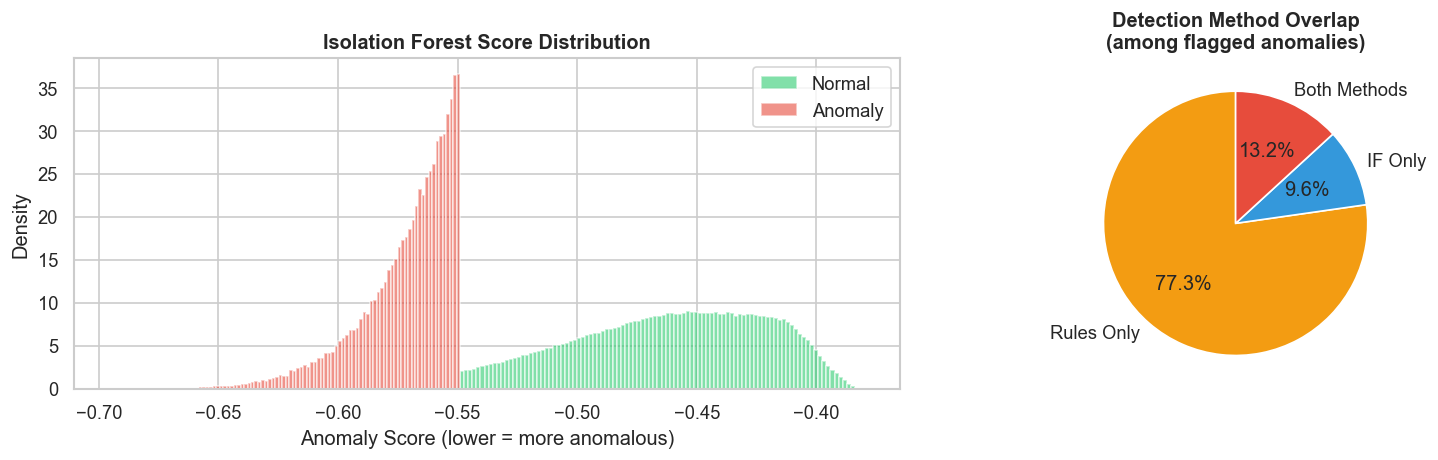

Rules only: 169,907
IF only:    21,019
Both:       28,981


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

normal_scores = df[df['if_anomaly'] == 0]['if_score']
anomaly_scores = df[df['if_anomaly'] == 1]['if_score']

axes[0].hist(normal_scores, bins=100, alpha=0.6, color='#2ecc71', label='Normal', density=True)
axes[0].hist(anomaly_scores, bins=100, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
axes[0].set_title('Isolation Forest Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Anomaly Score (lower = more anomalous)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Detection method overlap
both = ((df['rule_anomaly'] == 1) & (df['if_anomaly'] == 1)).sum()
rules_only = ((df['rule_anomaly'] == 1) & (df['if_anomaly'] == 0)).sum()
if_only = ((df['rule_anomaly'] == 0) & (df['if_anomaly'] == 1)).sum()

labels = ['Rules Only', 'IF Only', 'Both Methods']
sizes = [rules_only, if_only, both]
colors = ['#f39c12', '#3498db', '#e74c3c']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Detection Method Overlap\n(among flagged anomalies)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Rules only: {rules_only:,}')
print(f'IF only:    {if_only:,}')
print(f'Both:       {both:,}')

## 7. Ensemble & Final Decision <a id='7-ensemble'></a>

**Strategy:** A transaction is labeled anomalous if **either** approach flags it:
- Hard rules → always anomalous (high precision, interpretable, domain-backed)
- Isolation Forest → captures statistical outliers missed by explicit rules

This maximizes recall (we catch more real anomalies) without sacrificing too much precision, since IF operates on well-engineered features that already encode domain knowledge.

In [29]:
df['is_anomaly'] = ((df['rule_anomaly'] == 1) | (df['if_anomaly'] == 1)).astype(int)

total_anomalies = df['is_anomaly'].sum()
total = len(df)

print('=== Final Anomaly Detection Results ===')
print(f'Total transactions:      {total:,}')
print(f'Total anomalies:         {total_anomalies:,} ({total_anomalies/total:.2%})')
print(f'Normal transactions:     {total - total_anomalies:,} ({(total - total_anomalies)/total:.2%})')
print()
print(f'By detection source:')
print(f'  Rules only:            {rules_only:,}')
print(f'  Isolation Forest only: {if_only:,}')
print(f'  Both methods:          {both:,}')

=== Final Anomaly Detection Results ===
Total transactions:      1,000,000
Total anomalies:         219,907 (21.99%)
Normal transactions:     780,093 (78.01%)

By detection source:
  Rules only:            169,907
  Isolation Forest only: 21,019
  Both methods:          28,981


## 8. Deep-Dive Anomaly Analysis <a id='8-analysis'></a>

### 8.1 Anomaly Rate by Key Dimensions

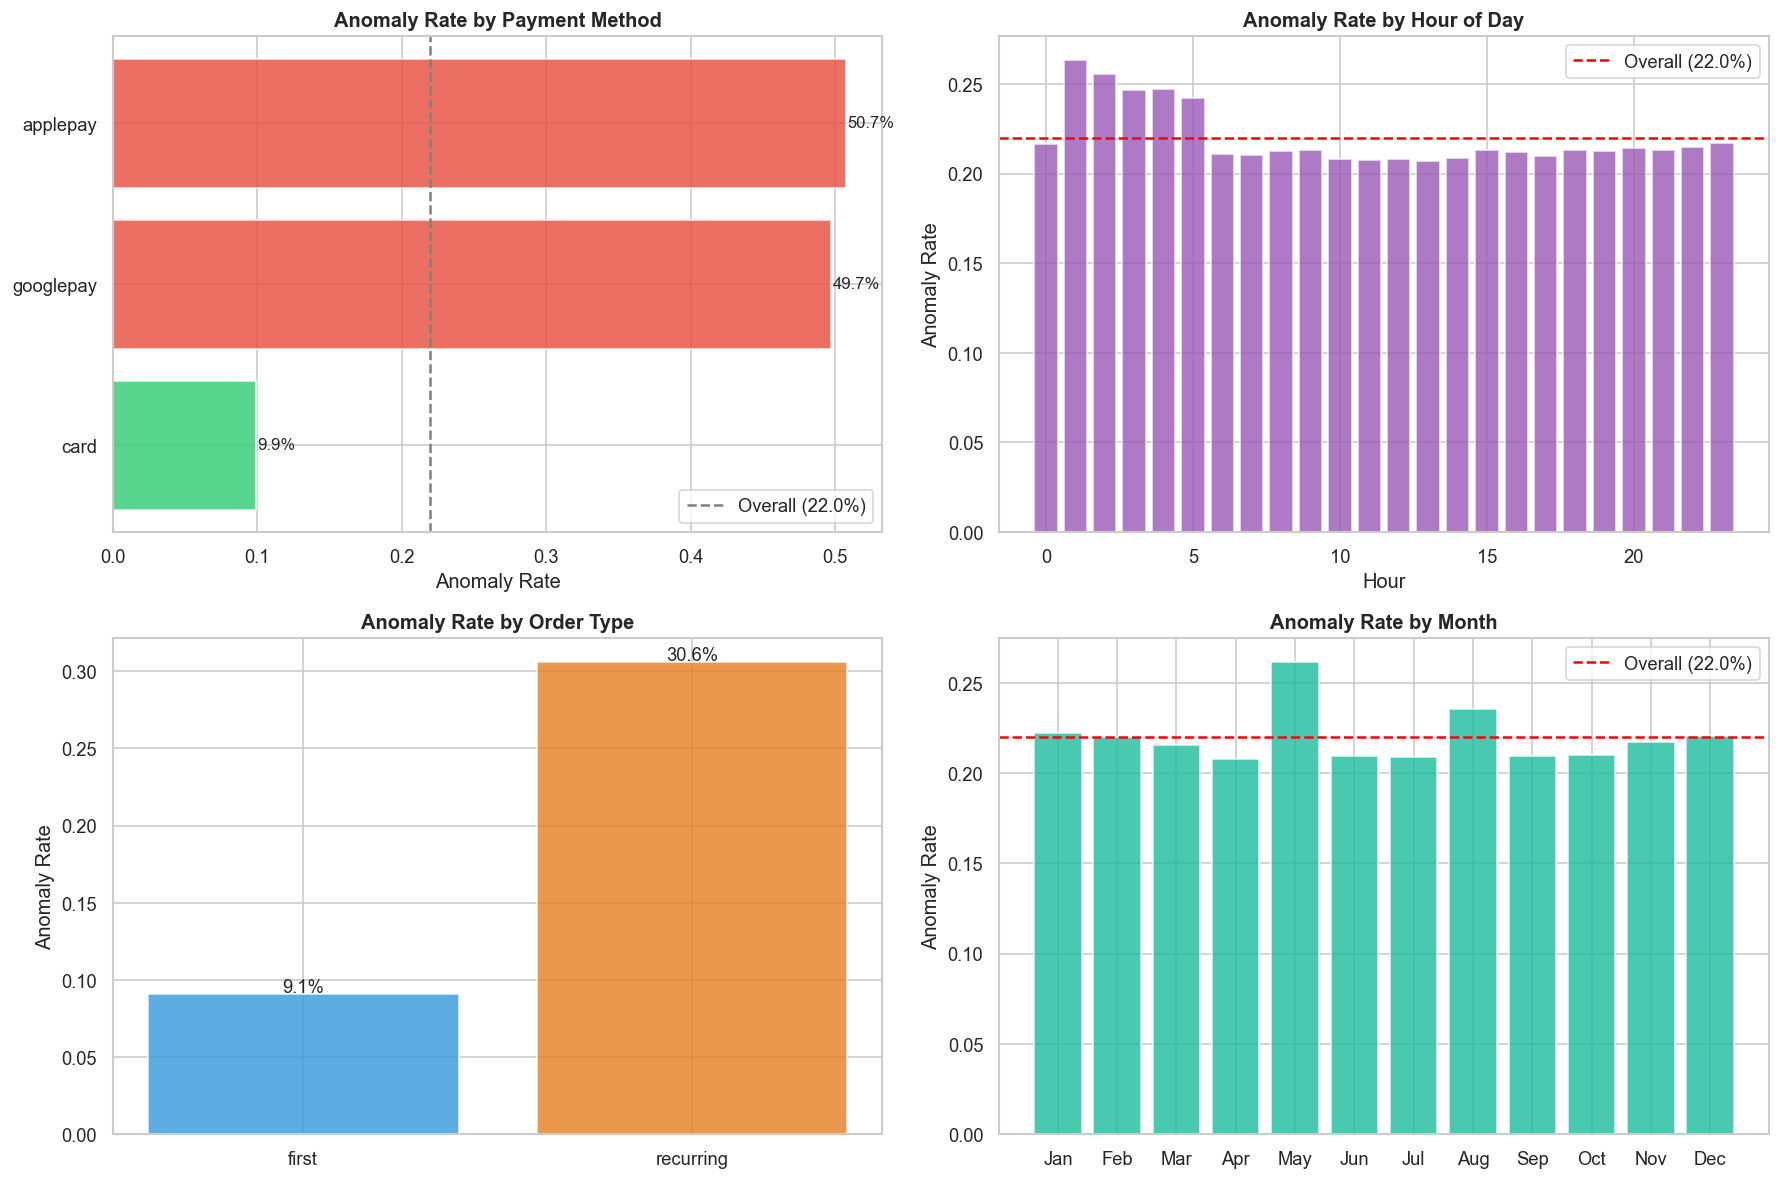

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
overall_rate = df['is_anomaly'].mean()

# By payment method
pm_anomaly = df.groupby('payment_method')['is_anomaly'].mean().sort_values()
axes[0, 0].barh(pm_anomaly.index, pm_anomaly.values,
                color=['#2ecc71' if v < overall_rate * 1.2 else '#e74c3c' for v in pm_anomaly.values],
                alpha=0.8)
axes[0, 0].axvline(overall_rate, color='gray', linestyle='--', label=f'Overall ({overall_rate:.1%})')
axes[0, 0].set_title('Anomaly Rate by Payment Method', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Anomaly Rate')
axes[0, 0].legend()
for i, v in enumerate(pm_anomaly.values):
    axes[0, 0].text(v + 0.001, i, f'{v:.1%}', va='center', fontsize=10)

# By hour of day
hour_anomaly = df.groupby('hour')['is_anomaly'].mean()
axes[0, 1].bar(hour_anomaly.index, hour_anomaly.values, color='#9b59b6', alpha=0.8)
axes[0, 1].axhline(overall_rate, color='red', linestyle='--', label=f'Overall ({overall_rate:.1%})')
axes[0, 1].set_title('Anomaly Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Anomaly Rate')
axes[0, 1].legend()

# By order type
ot_anomaly = df.groupby('order_type')['is_anomaly'].mean()
axes[1, 0].bar(ot_anomaly.index, ot_anomaly.values, color=['#3498db', '#e67e22'], alpha=0.8)
axes[1, 0].set_title('Anomaly Rate by Order Type', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Anomaly Rate')
for i, v in enumerate(ot_anomaly.values):
    axes[1, 0].text(i, v + 0.001, f'{v:.1%}', ha='center', fontsize=11)

# By month
month_anomaly = df.groupby('month')['is_anomaly'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1, 1].bar([month_names[m-1] for m in month_anomaly.index], month_anomaly.values,
               color='#1abc9c', alpha=0.8)
axes[1, 1].axhline(overall_rate, color='red', linestyle='--', label=f'Overall ({overall_rate:.1%})')
axes[1, 1].set_title('Anomaly Rate by Month', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Anomaly Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 8.2 Scatter Plots: Processing Time vs Amount

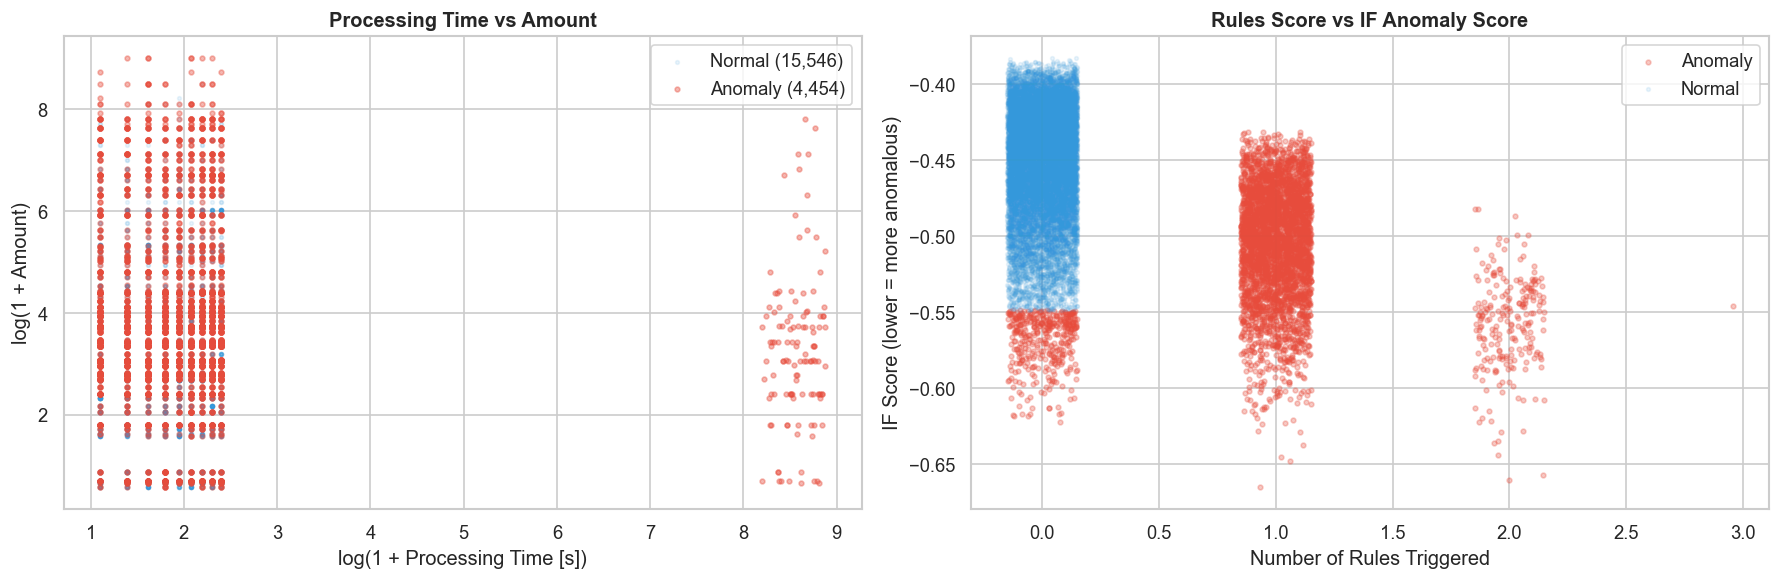

In [31]:
# Subsample for visualization performance (20k random points)
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(df), size=min(20000, len(df)), replace=False)
sample = df.iloc[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

normal_s = sample[sample['is_anomaly'] == 0]
anomaly_s = sample[sample['is_anomaly'] == 1]

axes[0].scatter(np.log1p(normal_s['processing_time']), np.log1p(normal_s['amount']),
                alpha=0.1, color='#3498db', s=5, label=f'Normal ({len(normal_s):,})')
axes[0].scatter(np.log1p(anomaly_s['processing_time']), np.log1p(anomaly_s['amount']),
                alpha=0.4, color='#e74c3c', s=8, label=f'Anomaly ({len(anomaly_s):,})')
axes[0].set_title('Processing Time vs Amount', fontsize=12, fontweight='bold')
axes[0].set_xlabel('log(1 + Processing Time [s])')
axes[0].set_ylabel('log(1 + Amount)')
axes[0].legend()

# IF score vs rule score
axes[1].scatter(anomaly_s['rule_score'] + np.random.uniform(-0.15, 0.15, len(anomaly_s)),
                anomaly_s['if_score'], alpha=0.3, color='#e74c3c', s=8, label='Anomaly')
axes[1].scatter(normal_s['rule_score'] + np.random.uniform(-0.15, 0.15, len(normal_s)),
                normal_s['if_score'], alpha=0.1, color='#3498db', s=5, label='Normal')
axes[1].set_title('Rules Score vs IF Anomaly Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Rules Triggered')
axes[1].set_ylabel('IF Score (lower = more anomalous)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.3 Top Most Anomalous Transactions

In [32]:
def build_explanation(row):
    reasons = []
    if row['R1_extreme_proc_time']:    reasons.append(f'proc_time={row["processing_time"]:.0f}s')
    if row['R2_over_refund']:          reasons.append(f'over_refund({row["refunded_amount"]:.2f}>{row["amount"]:.2f})')
    if row['R3_fraud_error']:          reasons.append(f'fraud_error={row["error_code"]}')
    if row['R4_wallet_autobilling']:   reasons.append(f'{row["payment_method"]}+{row["order_payment_type"]}')
    if row['R5_geo_fail_unsecured']:   reasons.append(f'geo({row["ip_country"]}≠{row["bin_country"]})+fail+no3DS')
    if row['R6_extreme_amount']:       reasons.append(f'zscore={row["amount_zscore_user"]:.1f}')
    if row['R7_high_velocity']:        reasons.append(f'velocity={row["user_tx_per_hour"]}tx/h')
    if row['R8_refund_inconsistency']: reasons.append('refund_inconsistency')
    return '; '.join(reasons) if reasons else 'IF_statistical_outlier'

anomalies = df[df['is_anomaly'] == 1].copy()
anomalies['explanation'] = anomalies.apply(build_explanation, axis=1)

display_cols = ['order_id', 'user_id', 'amount', 'currency', 'payment_method',
                'status', 'processing_time', 'rule_score', 'if_score', 'explanation']

print('=== Top 25 Most Anomalous Transactions (by IF score) ===')
anomalies.nsmallest(25, 'if_score')[display_cols]

=== Top 25 Most Anomalous Transactions (by IF score) ===


,order_id,user_id,amount,currency,payment_method,status,processing_time,rule_score,if_score,explanation
593394,593395,454374,6180.0000,UAH,card,success,3.0000,1,-0.6948,over_refund(6190.00>6180.00)
544952,544953,570709,3296.0000,UAH,applepay,success,3.0000,1,-0.6908,applepay+recurring
159527,159528,396418,4944.0000,UAH,applepay,fail,7.0000,2,-0.6871,applepay+rebill; geo(UKR≠DEU)+fail+no3DS
171248,171249,503457,8240.0000,UAH,applepay,fail,2.0000,1,-0.6843,applepay+retry
808696,808697,324248,4944.0000,UAH,applepay,success,8.0000,1,-0.6831,applepay+rebill
534101,534102,739217,1480.0000,MXN,googlepay,fail,3.0000,2,-0.6804,googlepay+retry; geo(MEX≠UKR)+fail+no3DS
473552,473553,622764,2060.0000,UAH,applepay,success,8.0000,1,-0.6761,applepay+retry
186394,186395,266133,1648.0000,UAH,googlepay,fail,3.0000,2,-0.6754,googlepay+recurring; geo(UKR≠POL)+fail+no3DS
291764,291765,915368,2060.0000,UAH,applepay,success,6.0000,1,-0.6749,applepay+rebill
979999,980000,158515,618.0000,UAH,applepay,success,8.0000,1,-0.6729,applepay+retry


### 8.4 Anomaly Pattern Summary

In [33]:
comparison_metrics = ['processing_time', 'amount', 'is_failed', 'is_geo_mismatch',
                      'is_secured_num', 'user_fail_rate', 'user_tx_per_hour']

comparison = pd.DataFrame({
    'Normal': df[df['is_anomaly'] == 0][comparison_metrics].mean(),
    'Anomaly': df[df['is_anomaly'] == 1][comparison_metrics].mean()
})
comparison['Ratio (Anomaly/Normal)'] = (comparison['Anomaly'] / comparison['Normal']).round(2)

print('=== Normal vs Anomaly Feature Comparison ===')
print(comparison.to_string())

print('\n=== Geographic Anomaly Patterns ===')
top_mismatch = (
    df[df['is_geo_mismatch'] == 1]
    .groupby(['ip_country', 'bin_country'])
    .agg(count=('order_id', 'count'), anomaly_rate=('is_anomaly', 'mean'))
    .reset_index()
    .nlargest(10, 'count')
)
print(top_mismatch.to_string(index=False))

=== Normal vs Anomaly Feature Comparison ===
                  Normal  Anomaly  Ratio (Anomaly/Normal)
processing_time   6.0009 139.5188                 23.2500
amount           83.3185 227.9941                  2.7400
is_failed         0.4416   0.5931                  1.3400
is_geo_mismatch   0.0733   0.3959                  5.4000
is_secured_num    0.0459   0.0298                  0.6500
user_fail_rate    0.4550   0.5454                  1.2000
user_tx_per_hour  1.0001   1.0002                  1.0000

=== Geographic Anomaly Patterns ===
ip_country bin_country  count  anomaly_rate
       USA         CAN  10435        0.5804
       USA         UKR  10389        0.5907
       USA         FRA  10359        0.5810
       USA         GBR  10350        0.5907
       USA         DEU  10298        0.5862
       USA         POL  10291        0.5858
       USA         MEX  10209        0.5892
       CAN         MEX   3184        0.5898
       CAN         POL   3176        0.5907
       CAN    

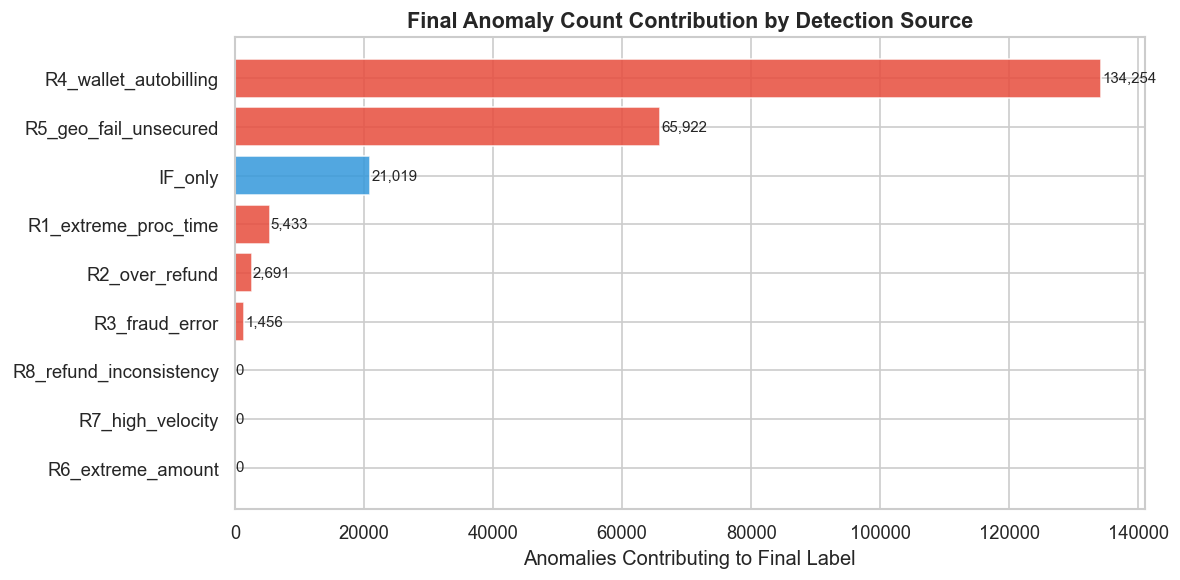


Total unique anomalies: 219,907


In [34]:
# Anomaly explanation breakdown
anomalies_with_exp = df[df['is_anomaly'] == 1].copy()
anomalies_with_exp['explanation'] = anomalies_with_exp.apply(build_explanation, axis=1)

# Rule contribution analysis
rule_contributions = {}
for rule in rule_names:
    flagged = df[df[rule] == 1]['is_anomaly'].sum()
    rule_contributions[rule] = flagged

if_only_count = ((df['rule_anomaly'] == 0) & (df['if_anomaly'] == 1)).sum()
rule_contributions['IF_only'] = if_only_count

fig, ax = plt.subplots(figsize=(10, 5))
sorted_contrib = sorted(rule_contributions.items(), key=lambda x: x[1])
labels_c = [r[0] for r in sorted_contrib]
values_c = [r[1] for r in sorted_contrib]
colors_c = ['#3498db' if l == 'IF_only' else '#e74c3c' for l in labels_c]
bars_c = ax.barh(labels_c, values_c, color=colors_c, alpha=0.85)
ax.set_title('Final Anomaly Count Contribution by Detection Source', fontsize=13, fontweight='bold')
ax.set_xlabel('Anomalies Contributing to Final Label')
for bar, val in zip(bars_c, values_c):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nTotal unique anomalies: {df["is_anomaly"].sum():,}')

## 9. Submission <a id='9-submission'></a>

In [35]:
submission = df[['order_id', 'is_anomaly']].copy()
submission['is_anomaly'] = submission['is_anomaly'].astype(int)

submission.to_csv(OUTPUT_PATH, index=False)

print(f'=== Submission Saved: {OUTPUT_PATH} ===')
print(f'Total rows:  {len(submission):,}')
print(f'Anomalies:   {submission["is_anomaly"].sum():,} ({submission["is_anomaly"].mean():.2%})')
print(f'Normal:      {(submission["is_anomaly"] == 0).sum():,}')
print()
submission.head(10)

=== Submission Saved: submission.csv ===
Total rows:  1,000,000
Anomalies:   219,907 (21.99%)
Normal:      780,093



,order_id,is_anomaly
0,1,1
1,2,0
2,3,0
3,4,0
4,5,1
5,6,0
6,7,0
7,8,0
8,9,0
9,10,0


In [36]:
# Final validation checks
print('=== Validation Checks ===')
checks = [
    ('Row count = 1,000,000', len(submission) == 1_000_000),
    ('No missing values', submission.isnull().sum().sum() == 0),
    ('Binary labels only {0,1}', set(submission['is_anomaly'].unique()).issubset({0, 1})),
    ('All order_ids unique', submission['order_id'].nunique() == len(submission)),
    ('order_ids match original', set(submission['order_id']) == set(df['order_id'])),
]
for desc, result in checks:
    status = 'PASS' if result else 'FAIL'
    print(f'  [{status}] {desc}')

=== Validation Checks ===
  [PASS] Row count = 1,000,000
  [PASS] No missing values
  [PASS] Binary labels only {0,1}
  [PASS] All order_ids unique
  [PASS] order_ids match original


---
## Summary of Findings

### Detected Anomaly Types

| Type | Rule | Description |
|------|------|-------------|
| Technical timeout | R1 | Transactions with >1 hour processing time — bank system stuck or infrastructure failure |
| Financial fraud | R2 | Refunded amount exceeds original charge — accounting manipulation or refund scheme |
| Confirmed fraud | R3 | Solidgate 5.xx error codes — bank-confirmed fraud/security events (stolen cards) |
| Payment inconsistency | R4 | Apple/Google Pay used for automated billing — technically impossible in legitimate systems |
| CNP fraud pattern | R5 | Geo mismatch + no 3DS + failed — classic card-not-present fraud signature |
| Unusual spending | R6 | Amount 5+ std deviations from user's normal — account takeover or card testing |
| Velocity attack | R7 | >5 transactions/hour from same user — bot activity or credential stuffing |
| Statistical outlier | IF | Multi-dimensional outliers not captured by explicit rules |

### Methodology
- **Fully unsupervised** — no labeled training data required
- **Hybrid approach**: 8 domain rules (high precision) + Isolation Forest (high recall)
- **26 engineered features** covering temporal, geographic, behavioral, and financial dimensions
- **Every anomaly is explainable** with a concrete business reason